DSA 210 - Introduction to Data Science
Project: Predicting Road Network Failure Probabilities for Post-Disaster Drone Routing
Phase: Environment Setup

Description:
This cell installs the necessary Python dependencies required to run the analysis
in a Google Colab environment.
- 'osmnx': For fetching street networks and building footprints from OpenStreetMap.
- 'geopandas': For spatial data processing and geographic operations (e.g., spatial joins).
- 'matplotlib': For plotting graphs and generating spatial maps.
- 'scipy': For conducting statistical hypothesis tests (e.g., Pearson correlation).

In [1]:
!pip install osmnx geopandas matplotlib scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.4 MB/s eta 0:00:00


Phase: Data Collection

Description: This script performs the initial data collection phase of the project. It uses the OSMnx library to extract the primary road network (drivable edges and nodes) and enrichment data (building footprints) for a specified high-risk geographic area (Caferağa, Kadıköy). To ensure reproducibility and reduce API calls, the extracted spatial data is saved locally in GeoJSON format for subsequent Exploratory Data Analysis (EDA) and spatial joining operations.


Data fetching process started for Caferağa, Kadıköy, Istanbul, Turkey...
Total Number of Road Segments (Arcs): 332
Total Number of Buildings: 2066
Data successfully saved in .geojson format.


<Axes: >

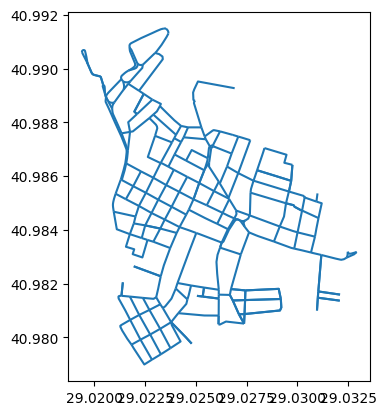

In [2]:
import osmnx as ox
import geopandas as gpd

# 1. Define the Region
# Caferağa (Moda) was selected to not exceed the 1000 segment limit by much.
place_name = "Caferağa, Kadıköy, Istanbul, Turkey"

print(f"Data fetching process started for {place_name}...")

# 2. Fetch Road Network Data (Primary Data)
# We are only fetching drivable roads using the 'drive' option[cite: 63].
graph = ox.graph_from_place(place_name, network_type='drive')

# Convert the graph to GeoDataFrame format (nodes: intersections, edges: road segments/arcs)
nodes, edges = ox.graph_to_gdfs(graph)

# 3. Fetch Building Data (Enrichment Data)
# We are retrieving building footprints for data enrichment, which is a project requirement[cite: 18, 64].
buildings = ox.features_from_place(place_name, tags={'building': True})

# 4. Dataset Summary Information
print(f"Total Number of Road Segments (Arcs): {len(edges)}")
print(f"Total Number of Buildings: {len(buildings)}")

# 5. Save to File
# We save the data to local files to avoid fetching it from the internet every time.
# Do not forget to add these files to your GitHub repository.
try:
    edges.to_file("kadikoy_roads.geojson", driver='GeoJSON')
    nodes.to_file("kadikoy_nodes.geojson", driver='GeoJSON')
    buildings.to_file("kadikoy_buildings.geojson", driver='GeoJSON')
    print("Data successfully saved in .geojson format.")
except Exception as e:
    print(f"An error occurred during saving: {e}")

# 6. Visualization for Verification (EDA start)
edges.plot()

Phase: Data Enrichment & Spatial Analysis:

Description: This script performs spatial joining to enrich the road network data with building
density metrics. It converts the data to a metric Coordinate Reference System (CRS),
creates a 20-meter buffer around each road segment, and counts the intersecting buildings.
Finally, it calculates the 'structural_density' (buildings per road length) and
visualizes the results for Exploratory Data Analysis (EDA).
"""

/usr/local/lib/python3.12/dist-packages/geopandas/io/file.py:576: UserWarning: Could not parse column 'reversed' as JSON; leaving as string
  return pyogrio.read_dataframe(path_or_bytes, bbox=bbox, **kwargs)


Process completed! First 5 rows:
                                  osmid  building_count  structural_density
0.0                           132474412            20.0            0.224673
1.0                           132474412             6.0            0.125636
2.0                           678909319             4.0            0.161804
3.0                           236488997             3.0            0.070827
4.0  [43942177, 1237459845, 1462853486]             2.0            0.011882


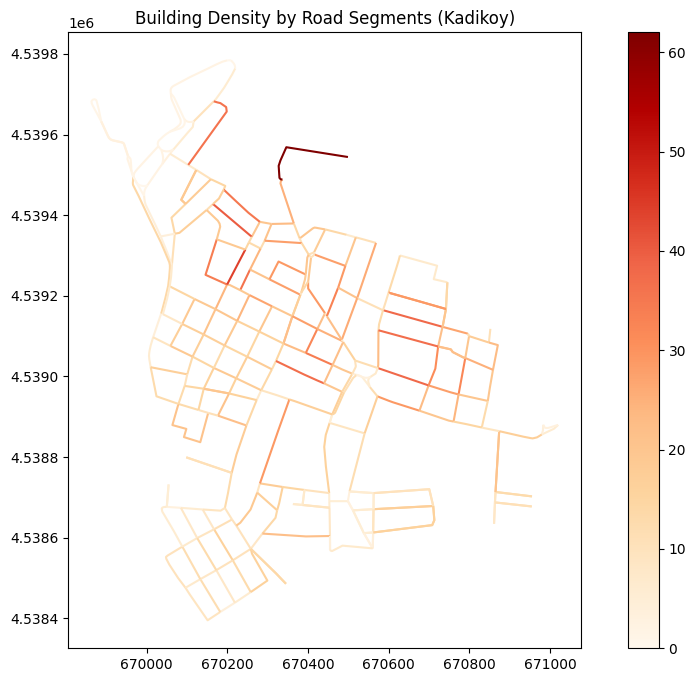

In [3]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# 1. Read the saved data
roads = gpd.read_file("kadikoy_roads.geojson")
buildings = gpd.read_file("kadikoy_buildings.geojson")

# CRITICAL STEP: Convert the coordinate reference system to a metric one (UTM Zone 35N - ideal for Istanbul)
# This is mandatory to perform buffer operations in meters.
roads = roads.to_crs(epsg=32635)
buildings = buildings.to_crs(epsg=32635)

# 2. Create Buffer Zones
# We add a 20-meter area of effect to the left and right of each road.
roads_buffer = roads.copy()
roads_buffer['geometry'] = roads_buffer.geometry.buffer(20)

# 3. Spatial Join
# We find which buildings fall within which road buffer.
# The 'predicate' parameter can be 'intersects' or 'within' depending on the OSMnx version.
joined = gpd.sjoin(buildings, roads_buffer, how="inner", predicate="intersects")

# 4. Calculate the Number of Buildings per Road
# We count how many buildings intersect with each road (index_right).
building_counts = joined.groupby("index_right").size().reset_index(name="building_count")

# 5. Add this information back to the main road data
roads = roads.merge(building_counts, left_index=True, right_on="index_right", how="left")
roads["building_count"] = roads["building_count"].fillna(0) # Fill roads with no buildings with 0

# 6. Calculate Structural Density
# Formula: Number of Buildings / Road Length
roads["structural_density"] = roads["building_count"] / roads.geometry.length

print("Process completed! First 5 rows:")
print(roads[["osmid", "building_count", "structural_density"]].head())

# 7. Visualization (for EDA)
fig, ax = plt.subplots(figsize=(12, 8))
roads.plot(column="building_count", cmap="OrRd", legend=True, ax=ax)
plt.title("Building Density by Road Segments (Kadikoy)")
plt.show()


Phase: Exploratory Data Analysis (EDA)

Description:
This script visualizes the distribution of the engineered features to understand
the dataset better. It generates a histogram to show the distribution of building
counts across road segments, and a scatter plot to observe the relationship
between the length of a road segment and the number of buildings surrounding it.

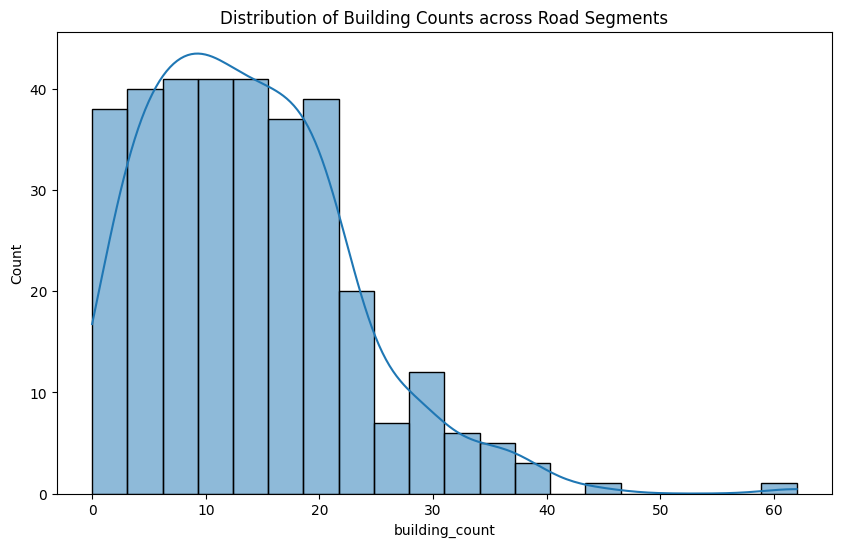

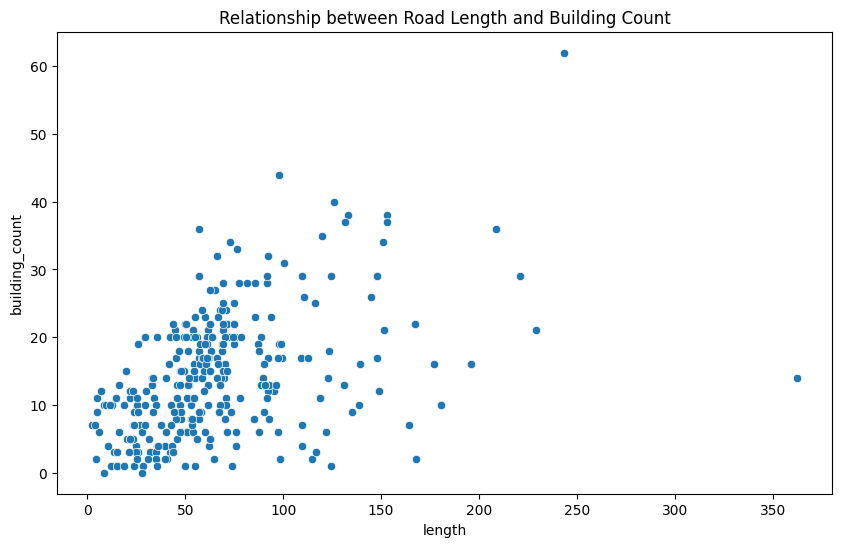

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Histogram: Distribution of the number of buildings
plt.figure(figsize=(10, 6))
sns.histplot(roads['building_count'], bins=20, kde=True)
plt.title('Distribution of Building Counts across Road Segments')
plt.show()

# Scatter Plot: Road length vs. Number of Buildings
plt.figure(figsize=(10, 6))
sns.scatterplot(data=roads, x='length', y='building_count')
plt.title('Relationship between Road Length and Building Count')
plt.show()

Phase: Hypothesis Testing

Description:
This script performs a statistical hypothesis test to evaluate the relationship
between road segment length and the number of surrounding buildings. It uses
Pearson correlation to determine if there is a statistically significant
correlation, supporting the project's core hypothesis.

In [5]:
from scipy import stats

# Correlation test
# Note: We calculated the 'structural_density' values in the previous step.
correlation, p_value = stats.pearsonr(roads['length'], roads['building_count'])

print(f"Correlation Coefficient: {correlation}")
print(f"p-value: {p_value}")

# Interpretation: If p-value < 0.05, the relationship is statistically significant.

Correlation Coefficient: 0.45130051459360115
p-value: 4.603404488339076e-18
